# UAV Crop-Weed Segmentation

See [project_plan.md](project_plan.md) for the project definition and task list. This notebook contains code, outputs, and concise technical explanations in English. Read and verify all code before submission.

## 1. Data Acquisition and Source Inspection

### 1.2 Data Acquisition

Reuse the pinned local archive when available; otherwise download it. Verify its checksum and extract original RGB images, masks, and dataset documentation only.

In [1]:
from pathlib import Path, PurePosixPath
import hashlib
import shutil
import urllib.request
import zipfile

DATASET_URL = "https://www.kaggle.com/datasets/bouhadjer/crop-weed-segmentation-uav-rgb-indices"
DOWNLOAD_URL = "https://www.kaggle.com/api/v1/datasets/download/bouhadjer/crop-weed-segmentation-uav-rgb-indices"
EXPECTED_SHA256 = "1cd9eddab9c5e132f679f0b223591c2ef549282920b447a693525f973e4775e3"

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "project_plan.md").exists():
    PROJECT_ROOT = PROJECT_ROOT / "final-project"
if not (PROJECT_ROOT / "project_plan.md").exists():
    raise FileNotFoundError("Run from the project folder or the course repository root.")

DOWNLOAD_DIR = PROJECT_ROOT / "data" / "downloads"
RAW_DIR = PROJECT_ROOT / "data" / "raw"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
ARCHIVE_PATH = DOWNLOAD_DIR / "dataset.zip"

if ARCHIVE_PATH.exists():
    print("Using the existing local archive.")
else:
    temporary_path = ARCHIVE_PATH.with_suffix(".zip.part")
    request = urllib.request.Request(DOWNLOAD_URL, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request, timeout=120) as response:
        with temporary_path.open("wb") as destination:
            shutil.copyfileobj(response, destination)
    with temporary_path.open("rb") as handle:
        downloaded_hash = hashlib.file_digest(handle, "sha256").hexdigest()
    if downloaded_hash != EXPECTED_SHA256:
        raise ValueError("Downloaded archive differs from the pinned snapshot. Review the dataset version before proceeding.")
    temporary_path.replace(ARCHIVE_PATH)
    print("Downloaded the dataset archive.")

with ARCHIVE_PATH.open("rb") as handle:
    archive_hash = hashlib.file_digest(handle, "sha256").hexdigest()
if archive_hash != EXPECTED_SHA256:
    raise ValueError("Archive checksum mismatch. Do not use this archive without review.")

original_count = 0
document_count = 0
with zipfile.ZipFile(ARCHIVE_PATH) as archive:
    for member in archive.infolist():
        if member.is_dir():
            continue
        path = PurePosixPath(member.filename)
        is_original = path.parent.name in {"img", "msk"}
        is_document = path.parent == PurePosixPath("Dataset") and path.suffix == ".txt"
        if not (is_original or is_document):
            continue
        relative = path.relative_to("Dataset")
        if ".." in relative.parts or relative.is_absolute():
            raise ValueError("Unsafe archive path.")
        target = RAW_DIR.joinpath(*relative.parts)
        content = archive.read(member)
        if target.exists():
            if target.read_bytes() != content:
                raise ValueError(f"Existing extracted file differs from the archive: {target}")
        else:
            target.parent.mkdir(parents=True, exist_ok=True)
            target.write_bytes(content)
        original_count += int(is_original)
        document_count += int(is_document)

print("Dataset:", DATASET_URL)
print("Archive:", ARCHIVE_PATH.relative_to(PROJECT_ROOT))
print("Archive bytes:", ARCHIVE_PATH.stat().st_size)
print("SHA-256:", archive_hash)
print("Original RGB and mask files:", original_count)
print("Dataset documentation files:", document_count)
print("Raw data:", RAW_DIR.relative_to(PROJECT_ROOT))


Using the existing local archive.
Dataset: https://www.kaggle.com/datasets/bouhadjer/crop-weed-segmentation-uav-rgb-indices
Archive: data/downloads/dataset.zip
Archive bytes: 2590700651
SHA-256: 1cd9eddab9c5e132f679f0b223591c2ef549282920b447a693525f973e4775e3
Original RGB and mask files: 42
Dataset documentation files: 3
Raw data: data/raw


### 1.4 File Inspection

Check original image-mask pairing and dimensions, validate mask colors, and review three trainval overlays. Test data undergo automatic integrity checks only; no model tuning or training statistics are computed.

In [2]:
import json
import numpy as np
from PIL import Image

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)
MASK_COLORS = np.array([[199, 199, 199], [31, 119, 180], [255, 127, 14]], dtype=np.uint8)
DATA_GROUPS = {
    "trainval": RAW_DIR / "trainval",
    "test": RAW_DIR / "test",
    "extra_bbch15": RAW_DIR / "test_different_bbch" / "BBCH15",
    "extra_bbch19": RAW_DIR / "test_different_bbch" / "BBCH19",
}


def index_files(folder, suffix):
    files = {}
    for path in sorted(folder.iterdir()):
        if not path.is_file() or path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        key = path.stem.removesuffix(suffix)
        if key in files:
            raise ValueError(f"Duplicate source identifier: {key}")
        files[key] = path
    return files


inspection_rows = []
source_pairs = {}
for group, folder in DATA_GROUPS.items():
    images = index_files(folder / "img", "_img")
    masks = index_files(folder / "msk", "_msk")
    if not images or images.keys() != masks.keys():
        missing_masks = sorted(images.keys() - masks.keys())
        missing_images = sorted(masks.keys() - images.keys())
        raise ValueError(f"{group}: missing masks={missing_masks}, missing images={missing_images}")
    for source_id, image_path in images.items():
        mask_path = masks[source_id]
        with Image.open(image_path) as image, Image.open(mask_path) as mask:
            image.load()
            mask.load()
            if image.size != mask.size:
                raise ValueError(f"Dimension mismatch: {group}/{source_id}")
            if image.mode != "RGB" or mask.mode != "RGB":
                raise ValueError(f"Expected original RGB image and RGB mask: {group}/{source_id}")
            mask_pixels = np.asarray(mask)
            valid_colors = np.zeros(mask_pixels.shape[:2], dtype=bool)
            for color in MASK_COLORS:
                valid_colors |= np.all(mask_pixels == color, axis=-1)
            unknown_count = int((~valid_colors).sum())
            if unknown_count:
                raise ValueError(f"Unexpected mask colors: {group}/{source_id}, pixels={unknown_count}")
            row = {"group": group, "source_id": source_id,
                   "image_path": image_path.relative_to(PROJECT_ROOT).as_posix(),
                   "mask_path": mask_path.relative_to(PROJECT_ROOT).as_posix(),
                   "width": image.width, "height": image.height,
                   "unknown_color_pixels": unknown_count}
            inspection_rows.append(row)
            source_pairs[(group, source_id)] = (image_path, mask_path)

file_inspection = {
    "scope": "Original RGB images and masks only; no model evaluation or split changes.",
    "groups": {group: sum(row["group"] == group for row in inspection_rows) for group in DATA_GROUPS},
    "checked_pairs": len(inspection_rows),
    "pairing_and_dimensions": "passed",
    "mask_colors": "passed",
    "visual_review": "pending",
    "files": inspection_rows,
}
(ARTIFACT_DIR / "FILE_INSPECTION.json").write_text(
    json.dumps(file_inspection, indent=2) + "\n", encoding="utf-8"
)
for group, count in file_inspection["groups"].items():
    print(f"{group}: {count} matched pairs, matching dimensions, valid mask colors.")
print(f"Automatic checks passed for {len(inspection_rows)} original image-mask pairs.")


trainval: 12 matched pairs, matching dimensions, valid mask colors.
test: 7 matched pairs, matching dimensions, valid mask colors.
extra_bbch15: 1 matched pairs, matching dimensions, valid mask colors.
extra_bbch19: 1 matched pairs, matching dimensions, valid mask colors.
Automatic checks passed for 21 original image-mask pairs.


Saved: artifacts/figures/file_inspection_overlays.png
Visual review is limited to these three trainval crops; test images are not displayed.


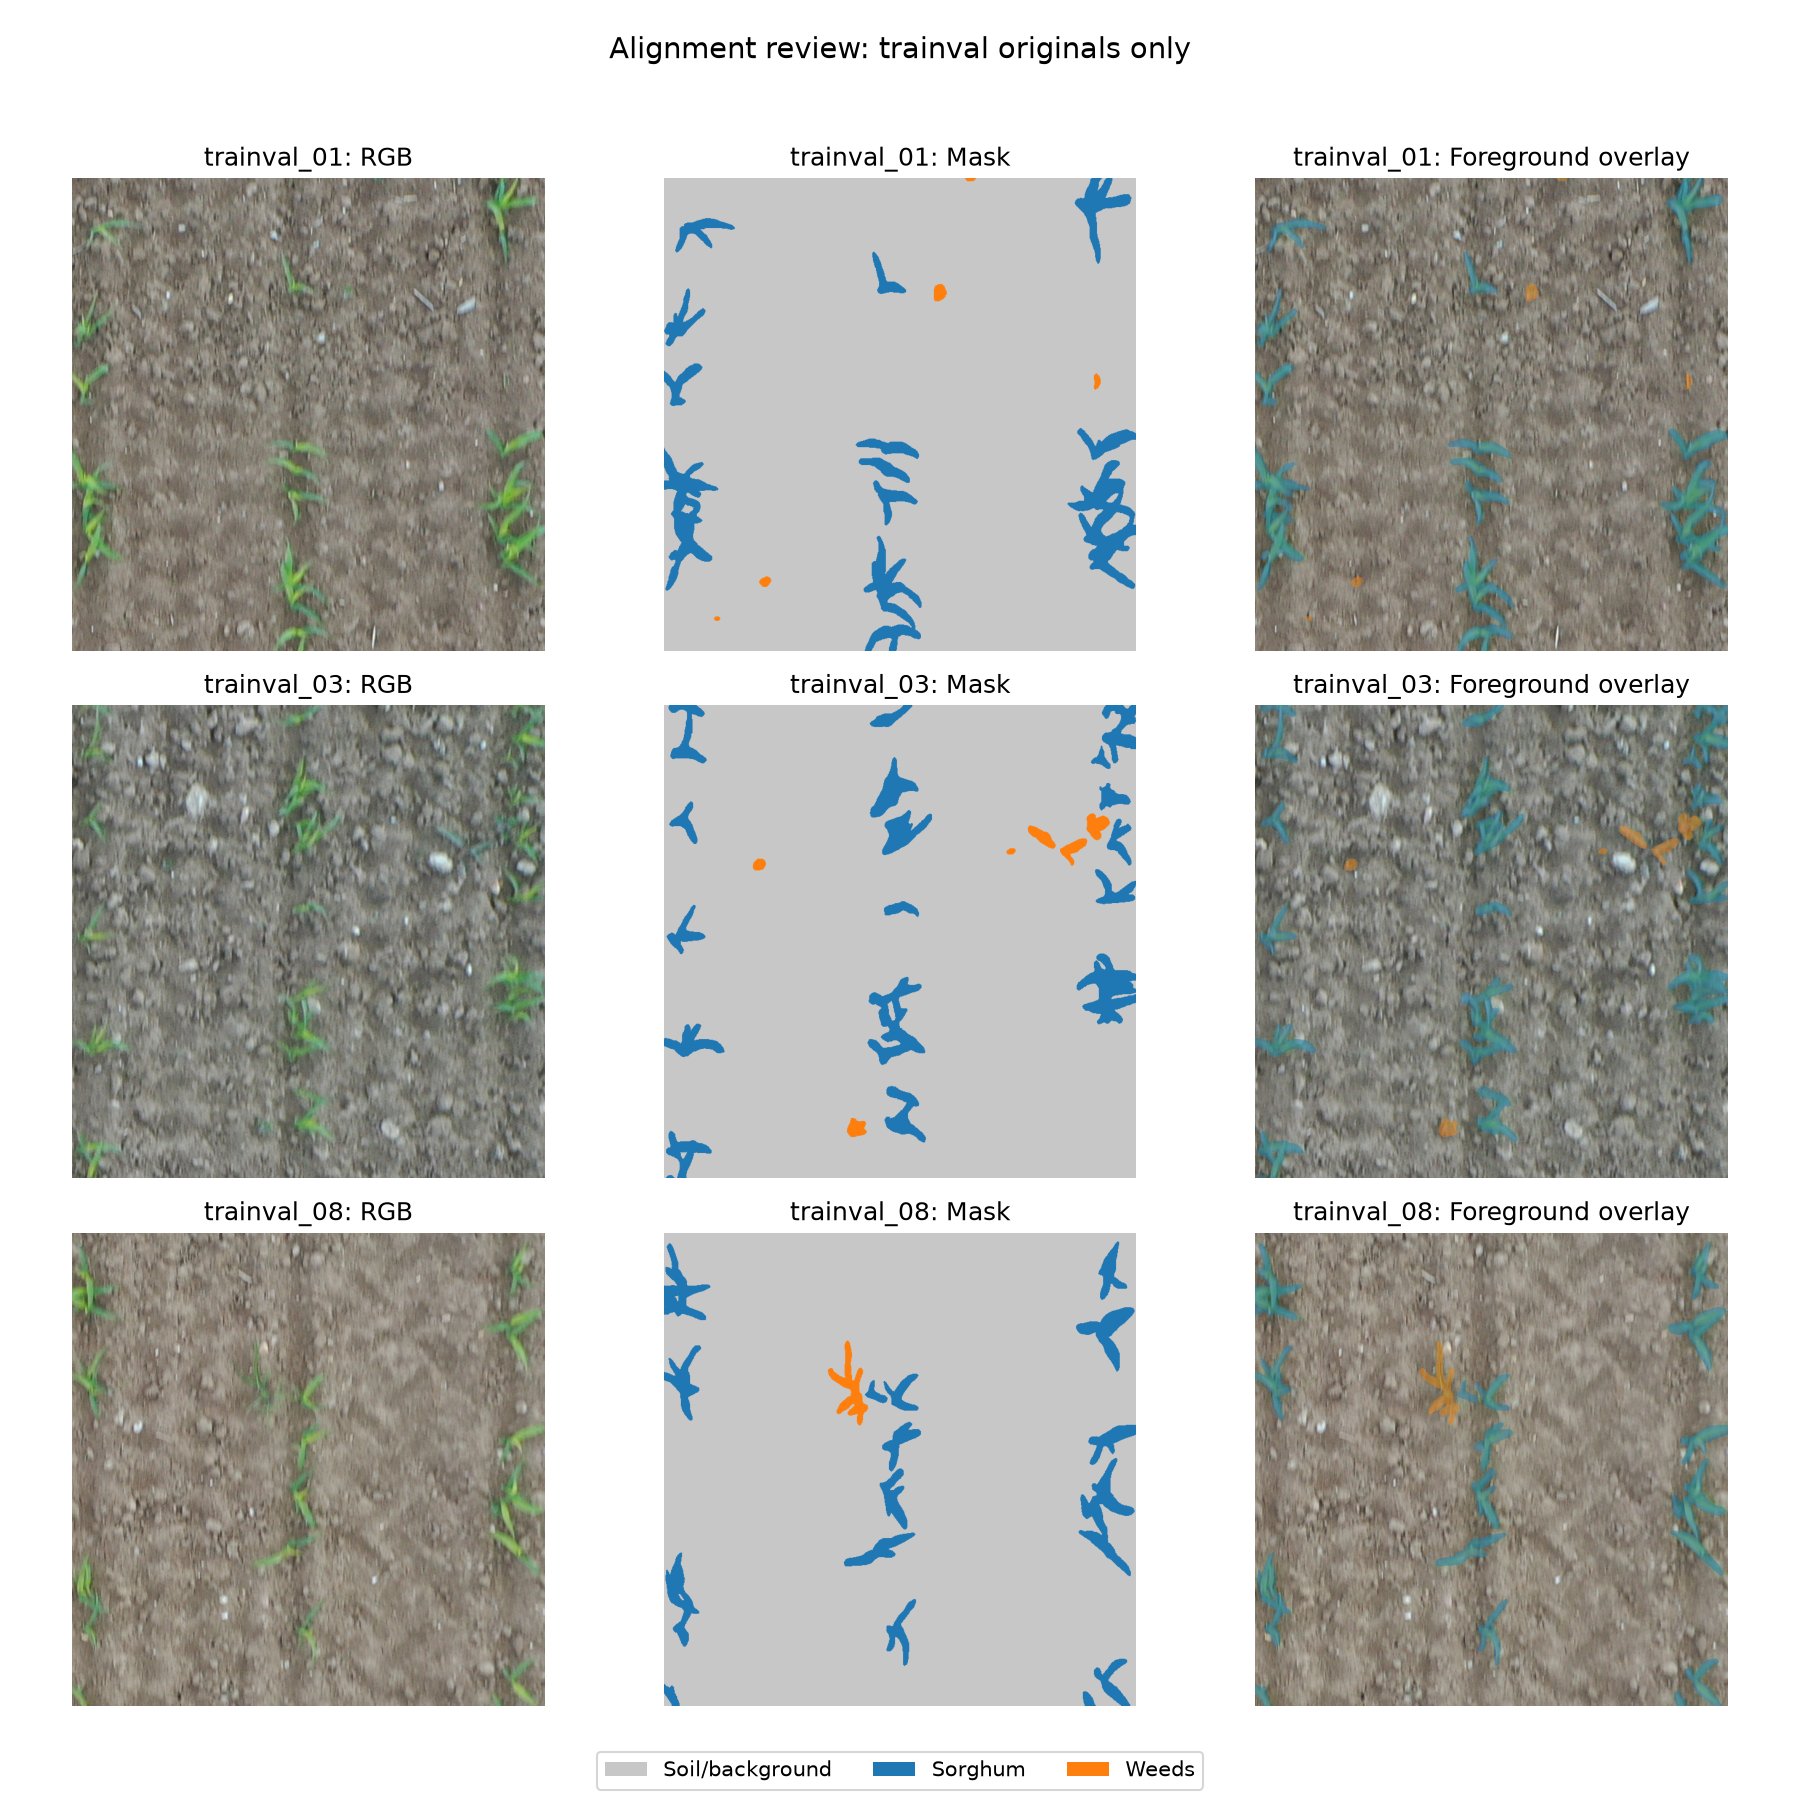

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

FIGURE_DIR = ARTIFACT_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)
VISUAL_SOURCES = ["trainval_01", "trainval_03", "trainval_08"]
CROP_SIZE = 768
visual_windows = []
figure, axes = plt.subplots(len(VISUAL_SOURCES), 3, figsize=(12, 12))
for row_index, source_id in enumerate(VISUAL_SOURCES):
    image_path, mask_path = source_pairs[("trainval", source_id)]
    with Image.open(image_path) as image, Image.open(mask_path) as mask:
        # Select a plant-containing window for alignment review, not for training.
        best_count = -1
        best_box = None
        for y in range(0, image.height - CROP_SIZE + 1, CROP_SIZE):
            for x in range(0, image.width - CROP_SIZE + 1, CROP_SIZE):
                box = (x, y, x + CROP_SIZE, y + CROP_SIZE)
                candidate = np.asarray(mask.crop(box))
                foreground = ~np.all(candidate == MASK_COLORS[0], axis=-1)
                count = int(foreground.sum())
                if count > best_count:
                    best_count, best_box = count, box
        if best_box is None:
            raise ValueError("Original image is smaller than the review crop.")
        rgb_crop = np.asarray(image.crop(best_box))
        mask_crop = np.asarray(mask.crop(best_box))
    overlay = rgb_crop.copy()
    foreground = ~np.all(mask_crop == MASK_COLORS[0], axis=-1)
    overlay[foreground] = np.rint(
        0.55 * rgb_crop[foreground] + 0.45 * mask_crop[foreground]
    ).astype(np.uint8)
    for column, (pixels, title) in enumerate([
        (rgb_crop, "RGB"), (mask_crop, "Mask"), (overlay, "Foreground overlay")
    ]):
        axes[row_index, column].imshow(pixels)
        axes[row_index, column].set_title(f"{source_id}: {title}")
        axes[row_index, column].axis("off")
    visual_windows.append({"source_id": source_id, "crop_box": list(best_box)})

figure.legend(handles=[
    Patch(facecolor=MASK_COLORS[index] / 255, label=label)
    for index, label in enumerate(["Soil/background", "Sorghum", "Weeds"])
], loc="lower center", ncol=3)
figure.suptitle("Alignment review: trainval originals only", fontsize=14)
figure.tight_layout(rect=(0, 0.04, 1, 0.96))
figure_path = FIGURE_DIR / "file_inspection_overlays.png"
figure.savefig(figure_path, dpi=150)
file_inspection["visual_windows"] = visual_windows
file_inspection["visual_figure"] = figure_path.relative_to(PROJECT_ROOT).as_posix()
(ARTIFACT_DIR / "FILE_INSPECTION.json").write_text(
    json.dumps(file_inspection, indent=2) + "\n", encoding="utf-8"
)
print("Saved:", figure_path.relative_to(PROJECT_ROOT))
print("Visual review is limited to these three trainval crops; test images are not displayed.")
plt.show()
plt.close(figure)


## 2. Source-Image Splitting

## 3. Data Exploration and Preprocessing

## 4. Baseline Models

## 5. U-Net Training

## 6. Evaluation, Ablation, and Error Analysis

## 7. Reproducibility and Report Outputs

## 8. Demonstration